# Calibration figures

Stylised-fact validation of the bare-market layer (no clearing) against empirical
ES front-month data, for both calibration regimes. The simulation uses the
behavioural $\theta$ from `model.globals.CALIBRATED[regime]` and runs on the
**empirical-mid fundamental** $V_t$ (`data/fv_*.csv`); the empirical target is the
raw ES mid (`data/processed/ES_front_*_1m.csv`) — the same series the calibration
loss targets and the data-summary table reports.

Contents, in order:

1. **Data summary** — descriptive statistics of the two empirical regimes, with a
   ready-to-paste LaTeX table (`tab:cal-data`).
2. **Stylised facts** — return distribution vs a Gaussian (KS/body), tail decay
   (log-log CCDF / Hill), autocorrelation of $r$ and $|r|$ (volatility
   clustering), and an empirical-vs-simulated price path.
3. **Moment table** — calibrated-vs-empirical moments side by side.

House style (navy / orange / grey palette, fonts, sizes) matches
`results_figures.ipynb`. Figures render inline; bump `SEEDS` / `NDAYS` in the
setup cell for thesis resolution.

## Data: summary statistics

Descriptive statistics of the two empirical regimes — the raw ES front-month mid
series the calibration targets. The cell below also prints a ready-to-paste LaTeX
table (`tab:cal-data`). One-minute returns drop overnight gaps; daily returns are
close-to-close (last mid per session).

In [1]:
# Thesis figures carry a LaTeX caption: suppress in-figure headers (suptitle) + boxed notes.
import matplotlib.figure as _mfig, matplotlib.axes as _maxes
_mfig.Figure.suptitle = lambda *a, **k: None
_maxes.Axes.text = (lambda _o: (lambda self, *a, **k: None if "bbox" in k else _o(self, *a, **k)))(_maxes.Axes.text)
# ============================================================================
# Table 4.1 — Empirical summary statistics for the two calibration regimes,
# built from the data so the thesis table (tab:cal-data) is reproducible here.
# Displays the actual table (no LaTeX). Sources: the 1-min mid
# (ES_front_{regime}_1m.csv, the series the calibration targets) for the
# one-minute and overnight-gap statistics and the drawdown; the daily bars
# (ES_front_daily_1d.csv), restricted to the regime's session dates, for the
# daily statistics. One-minute returns drop overnight gaps; the overnight gap is
# the RTH close-to-open session-boundary return; daily returns are close-to-close.
# ============================================================================
import numpy as np, pandas as pd
from scipy import stats as st

ONE_MIN = "data/processed/ES_front_{}_1m.csv"
DAILY   = "data/processed/ES_front_daily_1d.csv"

def regime_stats(regime):
    m = pd.read_csv(ONE_MIN.format(regime), index_col=0, parse_dates=True)
    mid   = m["mid"].to_numpy(float)
    dates = pd.DatetimeIndex(m.index).normalize()
    r     = np.diff(np.log(mid))
    boundary = dates.values[1:] != dates.values[:-1]        # return crosses a session boundary
    intraday, overnight = r[~boundary], r[boundary]          # overnight = RTH close-to-open gap
    max_dd = (mid / np.maximum.accumulate(mid) - 1.0).min()  # peak-to-trough of the mid
    # daily close-to-close from the separate daily file, on this regime's session dates
    d     = pd.read_csv(DAILY, index_col=0, parse_dates=True)
    sess  = pd.DatetimeIndex(dates.unique())
    close = d[pd.DatetimeIndex(d.index).normalize().isin(sess)]["close"].to_numpy(float)
    rd    = np.diff(np.log(close))
    return {
        "Sessions":               len(sess),
        "1-min SD (bps)":         intraday.std(ddof=1) * 1e4,
        "1-min ex. kurt.":        st.kurtosis(intraday),
        "Overnight gap SD (bps)": overnight.std(ddof=1) * 1e4,
        "Daily mean (%)":         rd.mean() * 100,
        "Daily SD (%)":           rd.std(ddof=1) * 100,
        "Max DD (%)":             max_dd * 100,
    }

tab_cal_data = pd.DataFrame({"Calm (2019)":     regime_stats("calm"),
                             "Stressed (2020)": regime_stats("stressed")}).T
tab_cal_data = tab_cal_data.round({"1-min SD (bps)": 2, "1-min ex. kurt.": 1,
    "Overnight gap SD (bps)": 0, "Daily mean (%)": 2, "Daily SD (%)": 2, "Max DD (%)": 1})
tab_cal_data["Sessions"] = tab_cal_data["Sessions"].astype(int)
try:
    display(tab_cal_data)
except NameError:
    print(tab_cal_data.to_string())


,Sessions,1-min SD (bps),1-min ex. kurt.,Overnight gap SD (bps),Daily mean (%),Daily SD (%),Max DD (%)
Calm (2019),75,2.4,55.0,30.0,0.10,0.61,-5.6
Stressed (2020),73,12.4,67.1,224.0,-0.15,3.38,-35.7


## Stylised facts — empirical vs simulated

Setup for the stylised-fact figures: the shared house style (matching
`results_figures.ipynb`) and the empirical / simulated return builders. The
simulated series is the model mid on a **bare market** (no clearing members:
`n_bcm = n_nbcm = 0`), run on the empirical-mid fundamental $V_t$ under
`globals.CALIBRATED[regime]`. Knobs `SEEDS` and `NDAYS` set the simulated-sample
size — bump both for thesis resolution.

In [2]:
# ============================================================================
# Setup: house style + data builders. Empirical = raw ES mid
# (data/processed/ES_front_*_1m.csv); simulated = model mid on the empirical-mid
# fundamental V_t under globals.CALIBRATED, bare market (no clearing tier).
# Figures render inline. Knobs: SEEDS (sim seeds), NDAYS (sim length in sessions).
# ============================================================================
import os
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from scipy.stats import norm
from model.globals import ModelParams, CALIBRATED, day_start_steps
from model.run_simulation import build_traders
from model.simulation import Simulation

SEEDS = [int(s) for s in os.environ.get("SEEDS", "42,7,123").split(",")]
NDAYS = int(os.environ.get("NDAYS", "18"))
REG = {"calm": "Calm (2019)", "stressed": "Stressed (COVID-19, 2020)"}

# house style (identical to results_figures.ipynb): navy / orange / grey + band
EMP_C, SIM_C, REF_C, BAND_C = "#1A5276", "#7FB3D5", "#9aa5b1", "#c8ced6"
plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "axes.edgecolor": "#5a5a5a", "axes.linewidth": 0.9, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": "#d4d8dd", "grid.linewidth": 0.7,
    "legend.fontsize": 9.5, "legend.frameon": False,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "xtick.color": "#5a5a5a", "ytick.color": "#5a5a5a",
})
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

def _intraday(r, opens):
    """Drop the overnight-gap return (the first return of each session)."""
    m = np.ones(len(r), bool)
    for o in opens:
        if 0 < o <= len(r): m[o - 1] = False
    return r[m]

def emp_returns(regime):
    """Empirical 1-min log returns (overnight gaps removed) + the mid series."""
    df = pd.read_csv(f"data/processed/ES_front_{regime}_1m.csv", index_col=0, parse_dates=True)
    mid = df["mid"].to_numpy(float); d = pd.DatetimeIndex(df.index).date
    r = np.diff(np.log(mid))
    return r[d[1:] == d[:-1]], mid

def sim_returns(regime, n_days=NDAYS):
    """Simulated 1-min log returns (intraday) + one mid path, over SEEDS seeds.
    Bare market on the empirical-mid fundamental V_t under CALIBRATED[regime]."""
    fv = pd.read_csv(f"data/fv_{regime}.csv"); V = fv["V_smooth"].to_numpy(float)
    SIG = fv["sigma_t"].to_numpy(float) if "sigma_t" in fv.columns else None
    st = list(day_start_steps(regime)); n = st[min(len(st) - 1, n_days)] if len(st) > n_days else len(V)
    out, sim_mid = [], None
    for seed in SEEDS:
        p = ModelParams(n_fundamental=40, n_momentum=20, n_zi=40, n_bcm=0, n_nbcm=0,
                        n_bcm_with_clients=0, v0=float(V[0]), tick_size=0.25, dt_minutes=1.0,
                        **CALIBRATED[regime], stressed=(regime == "stressed"))
        tr = build_traders(p, seed=seed)
        sim = Simulation(p, tr, seed=seed, ccp=None); sim.v_array = V[:n]
        if SIG is not None: sim.sigma_t_array = SIG[:n]
        sim.run(n)
        m = np.array([x for x in sim.history["mid_price"]], float); m = m[~np.isnan(m)]
        opens = [i for i in range(len(m)) if i in sim._day_start_rows]
        out.append(_intraday(np.diff(np.log(m)), opens))
        if sim_mid is None: sim_mid = m
    return np.concatenate(out), sim_mid, n

def acf(x, lags):
    x = x - x.mean(); v = np.dot(x, x)
    return np.array([np.dot(x[:-k], x[k:]) / v for k in lags])
def hill(x, frac=0.05):
    """Hill tail-index estimator on the top `frac` of |x| (cubic-law diagnostic)."""
    a = np.sort(np.abs(x))[::-1]; k = max(int(frac * len(a)), 20)
    return 1.0 / np.mean(np.log(a[:k] / a[k]))

DATA = {}
for rg in ("calm", "stressed"):
    e, emp_mid = emp_returns(rg); s, sim_mid, n = sim_returns(rg)
    DATA[rg] = dict(emp=e, sim=s, emp_mid=emp_mid[:n], sim_mid=sim_mid, n=n)
print("built DATA:", {rg: dict(emp=len(DATA[rg]["emp"]), sim=len(DATA[rg]["sim"])) for rg in DATA})

built DATA: {'calm': {'emp': 29961, 'sim': 21816}, 'stressed': {'emp': 28866, 'sim': 20643}}


### Return distribution vs the Gaussian benchmark

Empirical and simulated standardised-return CDFs against the standard Normal —
the heavy body / fat tails relative to the Gaussian.

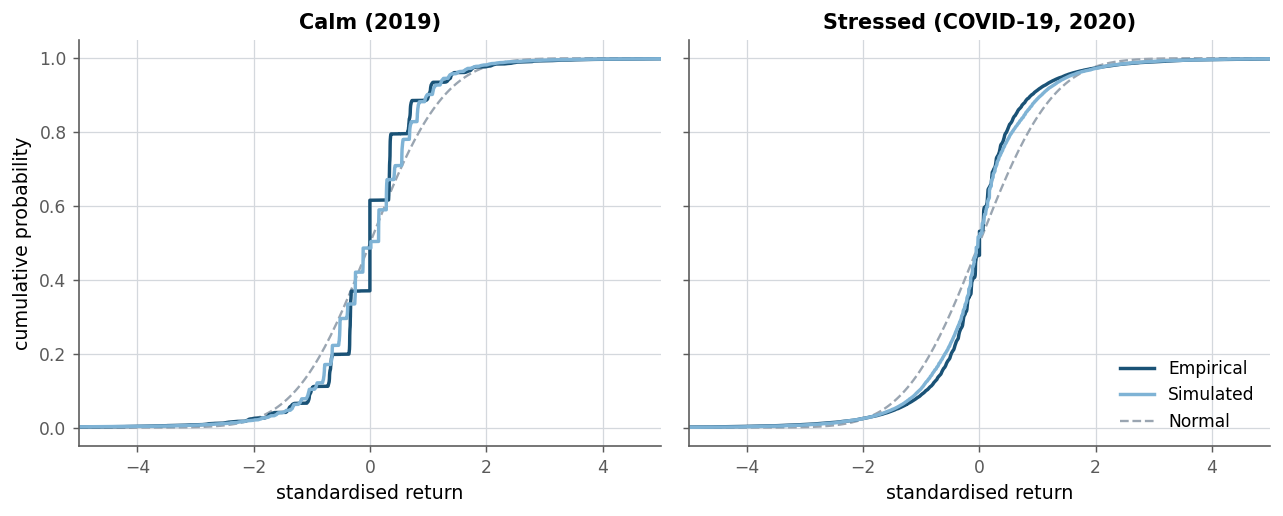

In [3]:
# ---- Fig 1: return distribution (CDF) vs the Gaussian benchmark ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4.1), sharey=True)
for ax, rg in zip(axes, ("calm", "stressed")):
    for lab, col in (("Empirical", EMP_C), ("Simulated", SIM_C)):
        x = DATA[rg]["emp"] if lab == "Empirical" else DATA[rg]["sim"]
        z = np.sort((x - x.mean()) / x.std()); cdf = np.arange(1, len(z) + 1) / len(z)
        ax.plot(z, cdf, color=col, lw=1.9, label=lab)
    zz = np.linspace(-5, 5, 200); ax.plot(zz, norm.cdf(zz), color=REF_C, lw=1.3, ls="--", label="Normal", zorder=1)
    ax.set_xlim(-5, 5); ax.set_title(REG[rg]); ax.set_xlabel("standardised return"); despine(ax)
axes[0].set_ylabel("cumulative probability"); axes[1].legend(loc="lower right")
fig.suptitle("Return distribution vs the Gaussian benchmark", fontweight="bold", fontsize=13, y=1.02)
fig.tight_layout(); plt.show()

### Tail index of returns (Hill estimator)

The Hill estimate of the tail index $\alpha$ as a function of the tail sample
fraction $k/n$; heavy-tailed (cubic-law) returns sit near $\alpha = 3$. This reads
more cleanly than a log-log survival plot, where the empirical and simulated curves
overlap and cross in the sparse extreme tail. The plotted path is lightly smoothed
for legibility; the single point estimate (at $k/n = 5\%$) is the one reported in
the moment table.

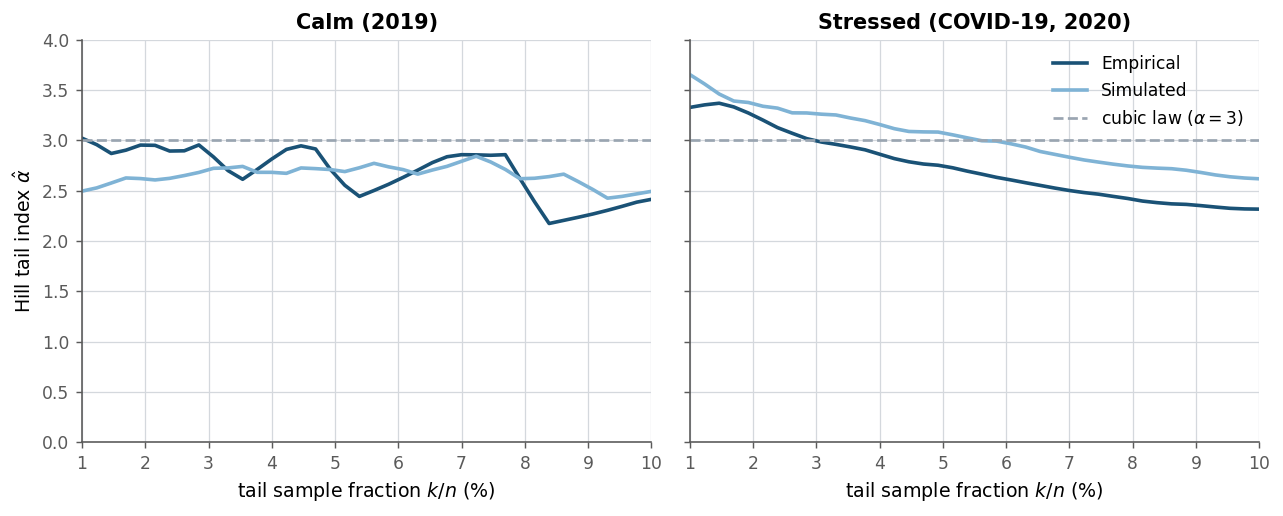

In [4]:
# ---- Fig 2: tail index of returns (Hill estimator) ----
# Hill alpha-hat vs tail fraction k/n; cubic-law heavy tails sit near alpha = 3.
def hill_curve(x, fracs):
    a = np.sort(np.abs(x))[::-1]; m = len(a)
    return np.array([1.0 / np.mean(np.log(a[:max(int(f * m), 15)] / a[max(int(f * m), 15)])) for f in fracs])
def _smooth(y, w=3):
    yp = np.pad(y, (w // 2, w // 2), mode="edge"); return np.convolve(yp, np.ones(w) / w, mode="valid")

fracs = np.linspace(0.01, 0.10, 40)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.1), sharey=True)
for ax, rg in zip(axes, ("calm", "stressed")):
    for lab, col in (("Empirical", EMP_C), ("Simulated", SIM_C)):
        x = DATA[rg]["emp"] if lab == "Empirical" else DATA[rg]["sim"]
        ax.plot(fracs * 100, _smooth(hill_curve(x, fracs)), color=col, lw=2.0, label=lab)
    ax.axhline(3.0, color=REF_C, ls="--", lw=1.5, label=r"cubic law ($\alpha=3$)")
    ax.set_xlim(1, 10); ax.set_ylim(0, 4); ax.set_title(REG[rg])
    ax.set_xlabel(r"tail sample fraction $k/n$ (%)"); despine(ax)
axes[0].set_ylabel(r"Hill tail index $\hat{\alpha}$"); axes[1].legend(loc="upper right")
fig.suptitle("Tail index of returns (Hill estimator)", fontweight="bold", fontsize=13, y=1.02)
fig.tight_layout(); plt.show()


### Return autocorrelation and volatility clustering

ACF of raw returns $r_t$ (near-zero — efficient prices) and of absolute returns
$|r_t|$ (slowly decaying — volatility clustering), with $\pm 1.96/\sqrt{N}$
significance bands.

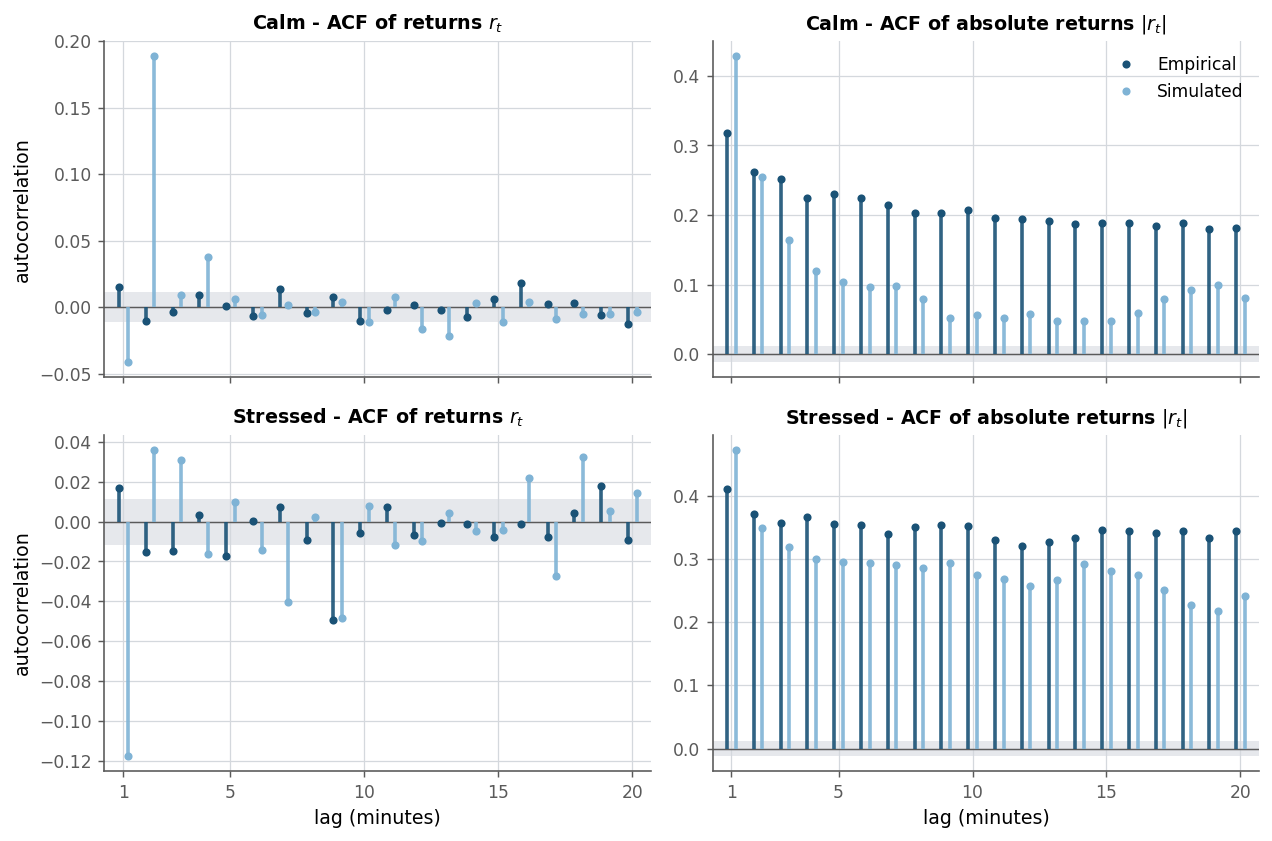

In [5]:
# ---- Fig 3: return autocorrelation and volatility clustering ----
lags = np.arange(1, 21)
fig, axes = plt.subplots(2, 2, figsize=(10, 6.6), sharex=True)
for i, rg in enumerate(("calm", "stressed")):
    for j, (nm, tx) in enumerate(((r"returns $r_t$", lambda v: v), (r"absolute returns $|r_t|$", np.abs))):
        ax = axes[i, j]
        b = 1.96 / np.sqrt(len(DATA[rg]["emp"]))
        ax.axhspan(-b, b, color=BAND_C, alpha=.45, lw=0, zorder=0)
        ax.axhline(0, color="#5a5a5a", lw=.8)
        for lab, col, off in (("Empirical", EMP_C, -0.16), ("Simulated", SIM_C, 0.16)):
            x = DATA[rg]["emp"] if lab == "Empirical" else DATA[rg]["sim"]
            a = acf(tx(x), lags)
            ax.vlines(lags + off, 0, a, color=col, lw=2.0, alpha=.9)
            ax.plot(lags + off, a, "o", color=col, ms=3.5, label=lab)
        ax.set_title(f"{REG[rg].split(' (')[0]} - ACF of {nm}", fontsize=10.5); despine(ax)
        ax.set_xticks([1, 5, 10, 15, 20]); ax.set_xlim(0.3, 20.7)
        if i == 1: ax.set_xlabel("lag (minutes)")
        if j == 0: ax.set_ylabel("autocorrelation")
axes[0, 1].legend(loc="upper right")
fig.suptitle("Return autocorrelation and volatility clustering", fontweight="bold", fontsize=13, y=1.005)
fig.tight_layout(); plt.show()


### Price path — empirical mid vs one simulated path

The empirical ES mid and one simulated path for both regimes: the full calibration
window (top row) and one representative session as an intraday zoom (bottom row).
$V_t$ is the empirical mid by construction, so the simulated mid is the layer of
model microstructure laid on top of the real trajectory.

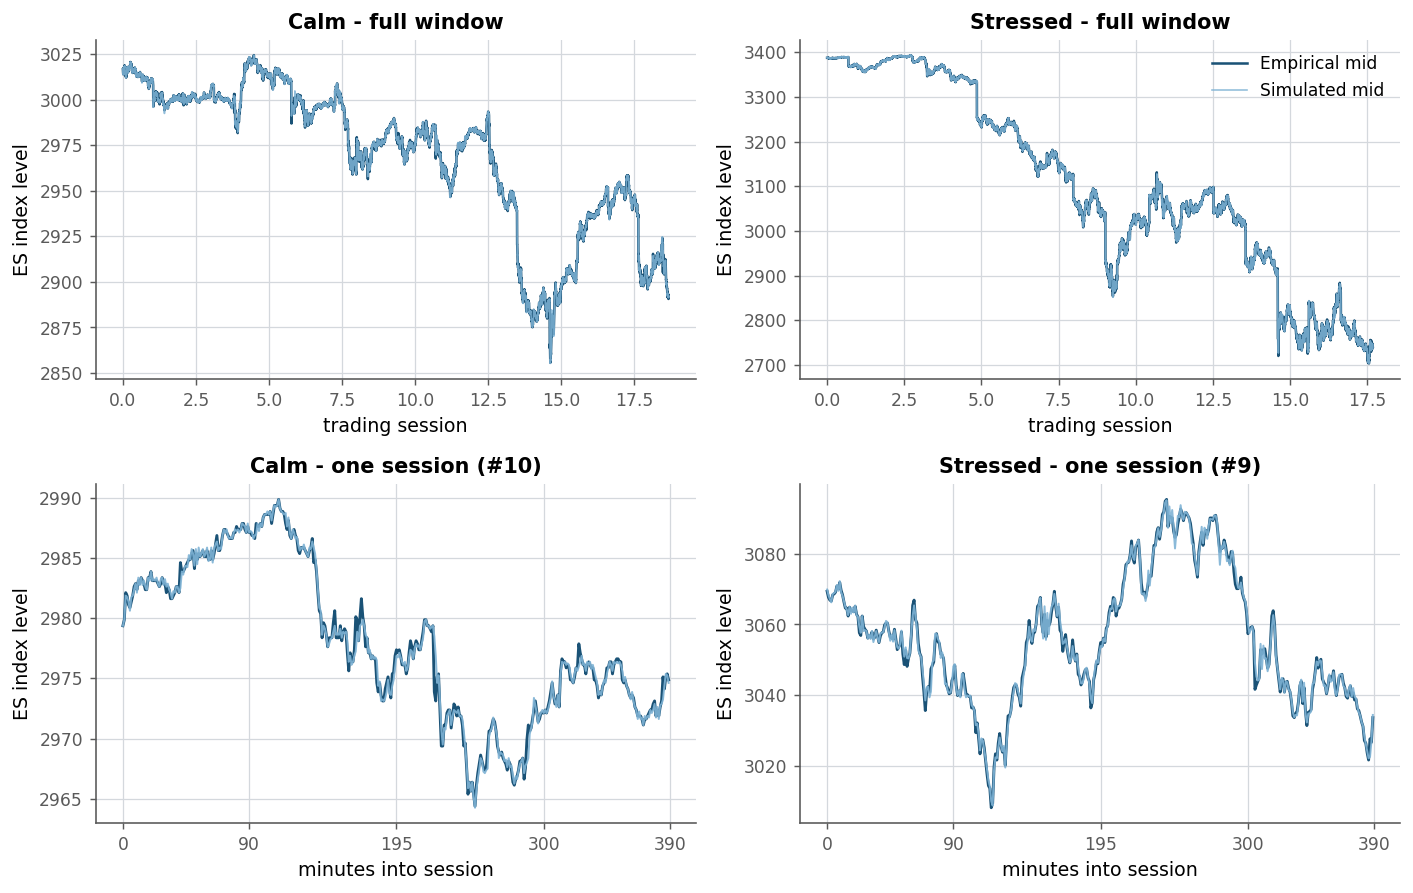

In [6]:
# ---- Fig 4: price path - empirical mid vs one simulated path (both regimes) ----
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for j, rg in enumerate(("calm", "stressed")):
    me = DATA[rg]["emp_mid"]; ms = DATA[rg]["sim_mid"]; Ln = min(len(me), len(ms))
    me, ms = me[:Ln], ms[:Ln]
    ax = axes[0, j]; t = np.arange(Ln) / 390.0          # full window (sessions on x)
    ax.plot(t, me, color=EMP_C, lw=1.4, label="Empirical mid")
    ax.plot(t, ms, color=SIM_C, lw=0.9, alpha=.85, label="Simulated mid")
    ax.set_title(REG[rg].split(" (")[0] + " - full window"); ax.set_xlabel("trading session")
    ax.set_ylabel("ES index level"); despine(ax)
    if j == 1: ax.legend(loc="best")
    sess = Ln // 390; sidx = max(0, sess // 2); a = sidx * 390; b = min(a + 390, Ln)
    ax = axes[1, j]; mins = np.arange(b - a)             # one-session intraday zoom
    ax.plot(mins, me[a:b], color=EMP_C, lw=1.6, label="Empirical mid")
    ax.plot(mins, ms[a:b], color=SIM_C, lw=1.1, alpha=.9, label="Simulated mid")
    ax.set_title(REG[rg].split(" (")[0] + f" - one session (#{sidx + 1})")
    ax.set_xlabel("minutes into session"); ax.set_ylabel("ES index level")
    ax.set_xticks([0, 90, 195, 300, 390]); despine(ax)
fig.suptitle("Price path - empirical mid vs one simulated path", fontweight="bold", fontsize=13, y=1.01)
fig.tight_layout(); plt.show()


## Calibrated-vs-empirical moments

The stylised-fact moments side by side — empirical vs simulated, per regime — for
the metrics summarised in the figures above: return SD, excess kurtosis, the Hill
tail index, and the $r$ / $|r|$ autocorrelations (the calibration-target moments).

In [7]:
# ---- Calibrated-vs-empirical moments (simulation uses globals.CALIBRATED) ----
def moments(x):
    return {"Std (bps)": x.std() / 1e-4, "Excess kurt.": pd.Series(x).kurt(),
            "Hill index": hill(x), "ACF r(1)": acf(x, [1])[0],
            "ACF |r|(1)": acf(np.abs(x), [1])[0], "ACF |r|(10)": acf(np.abs(x), [10])[0]}
rows = {}
for rg in ("calm", "stressed"):
    rows[f"{REG[rg].split(' (')[0]} — emp"] = moments(DATA[rg]["emp"])
    rows[f"{REG[rg].split(' (')[0]} — sim"] = moments(DATA[rg]["sim"])
mt = pd.DataFrame(rows).T
try: display(mt.round(3))
except NameError: print(mt.round(3).to_string())

,Std (bps),Excess kurt.,Hill index,ACF r(1),ACF |r|(1),ACF |r|(10)
Calm — emp,2.400,55.042,2.346,0.015,0.318,0.208
Calm — sim,3.132,20.176,2.675,-0.041,0.429,0.056
Stressed — emp,12.404,67.143,2.745,0.017,0.411,0.352
Stressed — sim,11.471,11.950,3.066,-0.117,0.473,0.275


## Clearing network structure

The tiered clearing arrangement used in the experiments: the CCP hub, the 15
clearing members (banking-with-clients, banking house-only, and non-banking,
alternating around the ring), and the 90 clients fanned out under their carrier.
Node area is proportional to capital.

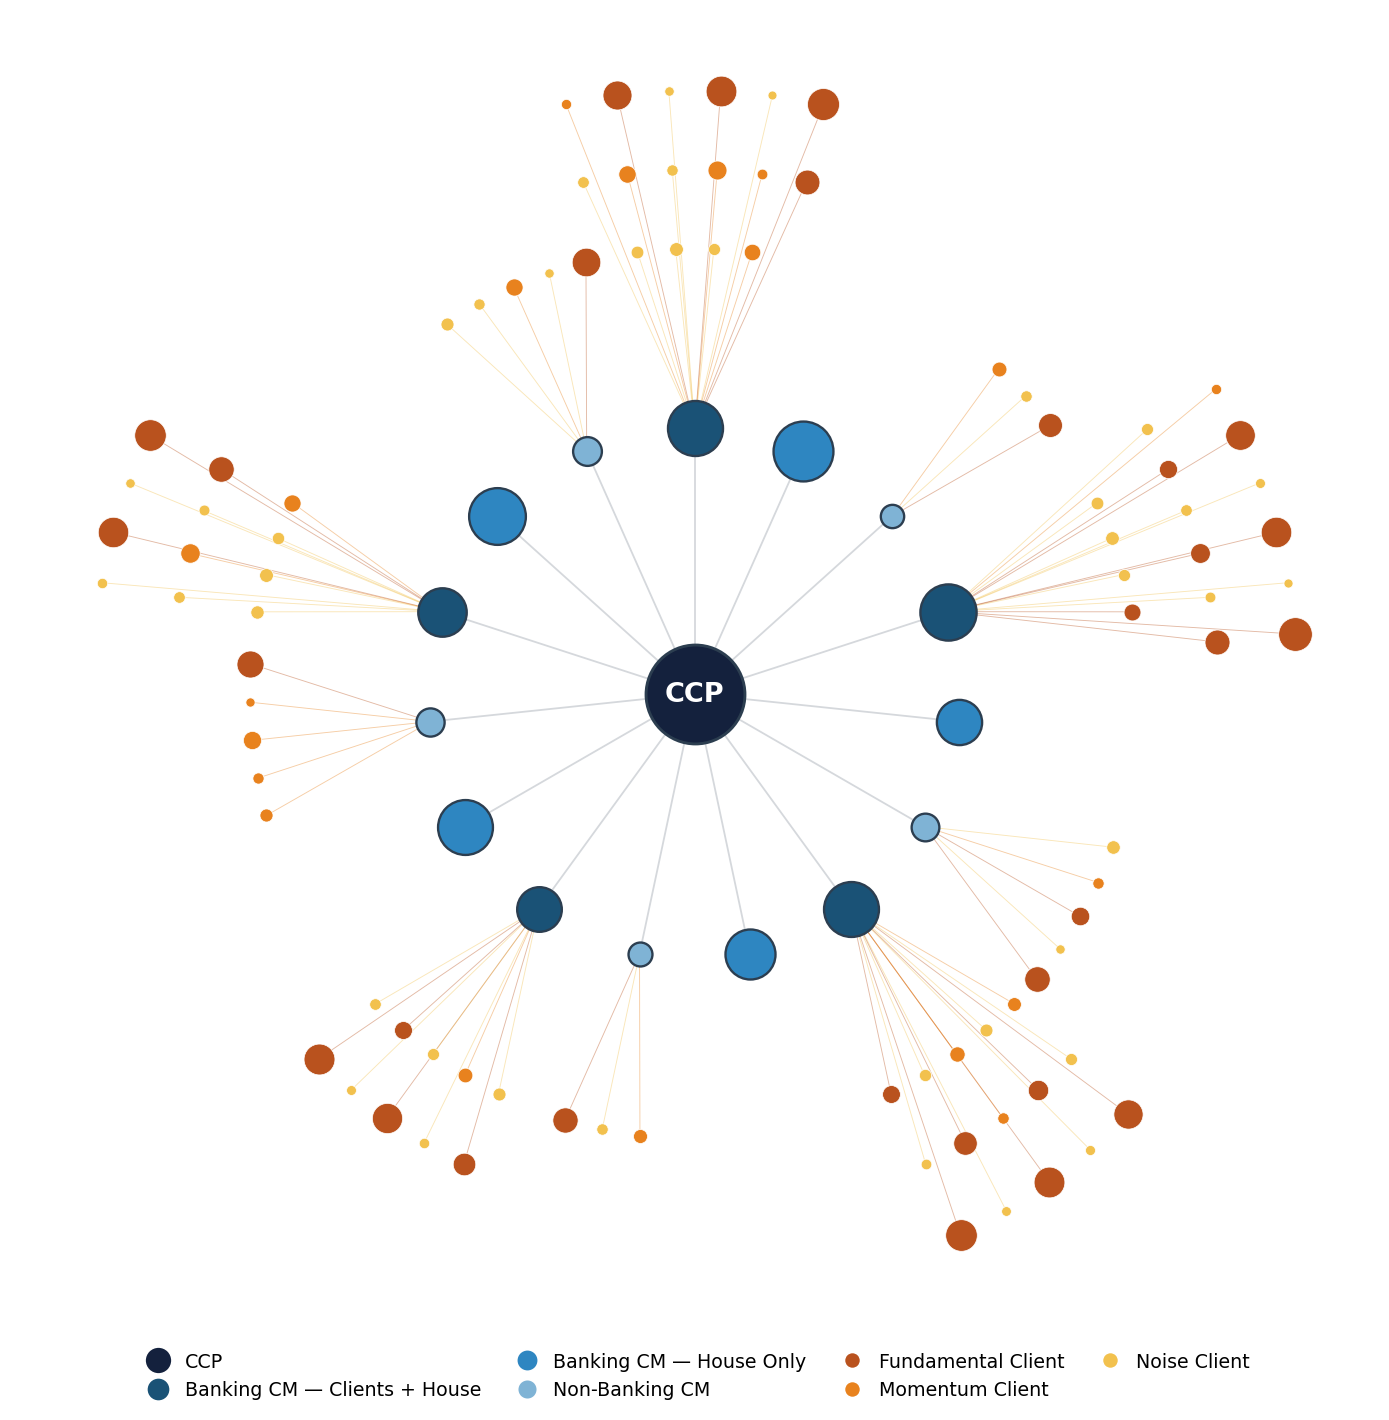

In [12]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from math import ceil
from model.globals import ModelParams, V0, CALIBRATED
from model.agents import (MomentumTrader, ZeroIntelligenceTrader, BankingClearingMember, NonBankingClearingMember)
from model.run_simulation import build_traders, build_clearing_tier

p=ModelParams(n_fundamental=30,n_momentum=20,n_zi=40,n_bcm=10,n_nbcm=5,n_bcm_with_clients=5,
              v0=V0["stressed"],tick_size=0.25,dt_minutes=1.0,**CALIBRATED["stressed"],stressed=True)
tr=build_traders(p,seed=42); ccp=build_clearing_tier(tr,p,seed=42); by={t.agent_id:t for t in tr}
C={"CCP":"#14213D","BCMc":"#1A5276","BCMo":"#2E86C1","NBCM":"#7FB3D5","FT":"#B9521E","MT":"#E8821E","ZI":"#F2C14E"}
bcms=[m for m in ccp.members.values() if isinstance(m,BankingClearingMember)]
nbcms=[m for m in ccp.members.values() if isinstance(m,NonBankingClearingMember)]
own=[m for m in bcms if not m.client_ids]; clibc=[m for m in bcms if m.client_ids]
order=[]
for i in range(5): order+=[clibc[i],own[i],nbcms[i]]
ctype=lambda c:"MT" if isinstance(c,MomentumTrader) else ("ZI" if isinstance(c,ZeroIntelligenceTrader) else "FT")
mcol=lambda m: C["NBCM"] if isinstance(m,NonBankingClearingMember) else (C["BCMc"] if m.client_ids else C["BCMo"])
capmax=max([m.cash for m in ccp.members.values()]+[by[c].cash for m in clibc+nbcms for c in m.client_ids])
SZ=lambda cash: max(9, 1100*cash/capmax)
nmem=len(order); step=2*np.pi/nmem
cen={m.agent_id: np.pi/2 - i*step for i,m in enumerate(order)}
R_MEM,R_CLI0,ROW=1.85,3.1,0.55
DOT_STEP=0.086; LEAN=0.0
def nrows(k): return 1 if k<=5 else (2 if k<=10 else 3)
def spread_sizes(cids):                               # interleave big/small so sizes are mixed
    s=sorted(cids,key=lambda c:-by[c].cash); out=[]; i,j=0,len(s)-1
    while i<=j:
        out.append(s[i]); i+=1
        if i<=j: out.append(s[j]); j-=1
    return out
mpos={m.agent_id:(R_MEM*np.cos(cen[m.agent_id]),R_MEM*np.sin(cen[m.agent_id])) for m in order}
fig,ax=plt.subplots(figsize=(11,11)); ax.axis("off"); ax.set_aspect("equal"); fig.patch.set_facecolor("white")
pts=[]
for m in order:
    x,y=mpos[m.agent_id]; ax.plot([x,0],[y,0],color="#D5D8DC",lw=1.0,zorder=1)
for i,m in enumerate(order):
    if not m.client_ids: continue
    left_ho=not order[(i-1)%nmem].client_ids; right_ho=not order[(i+1)%nmem].client_ids
    lean=(-LEAN if right_ho and not left_ho else (LEAN if left_ho and not right_ho else 0.0))  # toward empty house-only slot
    fc=cen[m.agent_id]+lean
    cids=spread_sizes(m.client_ids); k=len(cids); rows=nrows(k); ncol=ceil(k/rows); mx,my=mpos[m.agent_id]
    for jj,cid in enumerate(cids):
        g=jj//ncol; ri=(rows-1)-g                     # widen outward (outer rows full)
        cnt=min(ncol,k-g*ncol); ci=jj%ncol
        a=fc+(ci-(cnt-1)/2.0)*DOT_STEP
        r=R_CLI0+ri*ROW; cx,cy=r*np.cos(a),r*np.sin(a); col=C[ctype(by[cid])]
        ax.add_patch(FancyArrowPatch((mx,my),(cx,cy),connectionstyle="arc3,rad=0.0",arrowstyle="-",color=col,lw=0.5,alpha=0.4,zorder=2))
        ax.scatter([cx],[cy],s=SZ(by[cid].cash),color=col,edgecolors="white",linewidths=0.4,zorder=3); pts.append((cx,cy))
for m in order:
    x,y=mpos[m.agent_id]; ax.scatter([x],[y],s=SZ(m.cash),color=mcol(m),edgecolors="#2C3E50",linewidths=1.3,zorder=4); pts.append((x,y))
ax.scatter([0],[0],s=3000,color=C["CCP"],edgecolors="#2C3E50",linewidths=1.6,zorder=5)
ax.text(0,0,"CCP",ha="center",va="center",color="white",fontsize=15,fontweight="bold",zorder=6)
lim=max(max(abs(x),abs(y)) for x,y in pts)+0.55; ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim)
leg=[Line2D([0],[0],marker='o',color='w',markerfacecolor=C[k2],markersize=ms_,label=lb) for k2,ms_,lb in
     [("CCP",15,"CCP"),("BCMc",13,"Banking CM — Clients + House"),("BCMo",12,"Banking CM — House Only"),
      ("NBCM",11,"Non-Banking CM"),("FT",9,"Fundamental Client"),("MT",9,"Momentum Client"),("ZI",9,"Noise Client")]]
ax.legend(handles=leg,loc="lower center",bbox_to_anchor=(0.5,-0.03),ncol=4,fontsize=10.5,frameon=False,handletextpad=0.4,columnspacing=1.4)
fig.savefig("clearing_topology.png", dpi=200, bbox_inches="tight")
fig.tight_layout(); plt.show()


## Table — synthetic-fundamental out-of-sample validation (`tab:cal-synth`)

In [9]:
# tab:cal-synth — out-of-sample moment validation of the joint synthetic calibration (80 paths).
import pandas as pd
v = pd.read_csv("output/overnight_joint_logvol/validation.csv")
PRETTY = {"ret_std":"Return std","acf_r_1":"ACF r (1)","acf_r_5":"ACF r (5)","acf_r_10":"ACF r (10)",
          "acf_r_20":"ACF r (20)","acf_absr_1":"ACF |r| (1)","acf_absr_5":"ACF |r| (5)",
          "acf_absr_10":"ACF |r| (10)","acf_absr_20":"ACF |r| (20)","hill_tail_index":"Hill index"}
tab = v.assign(Moment=v.moment.map(lambda m: PRETTY.get(m, m)))[["Moment","empirical","joint_mean","joint_gapSD","joint_in95"]]
tab.columns = ["Moment","Empirical","Joint mean","|d|/s (SD)","in 95% CI"]
cov = int((v.joint_in95 == "yes").sum())
print(f"joint coverage: {cov}/{len(v)} moments inside the empirical 95% CI; "
      f"mean standardised gap {v.joint_gapSD.abs().mean():.2f} SD")
try:
    display(tab.round(4))
except NameError:
    print(tab.round(4).to_string(index=False))


joint coverage: 9/10 moments inside the empirical 95% CI; mean standardised gap 0.64 SD


,Moment,Empirical,Joint mean,|d|/s (SD),in 95% CI
0,Return std,0.0012,0.0012,0.20,yes
1,ACF r (1),-0.0045,-0.0188,2.68,no
2,ACF r (5),-0.0033,-0.0030,0.04,yes
3,ACF r (10),-0.0018,-0.0010,0.17,yes
4,ACF r (20),-0.0046,-0.0020,0.47,yes
5,ACF |r| (1),0.3793,0.3887,0.57,yes
6,ACF |r| (5),0.3495,0.3375,0.50,yes
7,ACF |r| (10),0.3339,0.3263,0.36,yes
8,ACF |r| (20),0.3377,0.3150,1.30,yes
9,Hill index,2.7274,2.7123,0.11,yes


## Table — moment coverage ratio (`tab:cal-mcr`)

In [10]:
# tab:cal-mcr — Moment Coverage Ratio (MCR, %) per moment, both regimes (from output/mcr_{regime}.json).
import json, pandas as pd
PRETTY = {"ret_std":"Return std","acf_r_1":"ACF r (1)","acf_r_5":"ACF r (5)","acf_r_10":"ACF r (10)",
          "acf_r_20":"ACF r (20)","acf_absr_1":"ACF |r| (1)","acf_absr_5":"ACF |r| (5)",
          "acf_absr_10":"ACF |r| (10)","acf_absr_20":"ACF |r| (20)","hill_tail_index":"Hill index"}
rows = {}
for reg in ["calm","stressed"]:
    d = json.load(open(f"output/mcr_{reg}.json"))
    col = {PRETTY.get(m,m): (v.get("mcr_pct") if isinstance(v,dict) else v) for m,v in d["moments"].items()}
    col["Joint MCR"] = d.get("joint_mcr_pct")
    rows[reg.capitalize()] = col
tab = pd.DataFrame(rows)
try: display(tab.round(1))
except NameError: print(tab.round(1).to_string())


,Calm,Stressed
Return std,0.0,100.0
ACF r (1),0.0,88.8
ACF r (5),45.0,100.0
ACF r (10),65.0,100.0
ACF r (20),83.8,100.0
ACF |r| (1),2.5,6.2
ACF |r| (5),0.0,100.0
ACF |r| (10),0.0,97.5
ACF |r| (20),0.0,76.2
Hill index,12.5,100.0


## Table — calibrated agent parameters (`tab:model-params`)

In [11]:
# tab:model-params — the 7 calibrated trading-agent parameters, by regime (from model.globals.CALIBRATED).
import pandas as pd
from model import globals as G
SYM = {"ft_sigma_c":"c_f  (FT belief width)","mt_lambda":"lambda  (MT decay)","mt_gamma":"gamma_M  (MT activation)",
       "zi_alpha":"alpha_zi  (ZI limit rate)","zi_mu":"mu_zi  (ZI market rate)","zi_delta":"delta_zi  (ZI cancel rate)",
       "p_zi":"p_d  (geometric depth)"}
order = ["ft_sigma_c","mt_lambda","mt_gamma","zi_alpha","zi_mu","zi_delta","p_zi"]
tab = pd.DataFrame({reg.capitalize(): {SYM[k]: G.CALIBRATED[reg].get(k) for k in order} for reg in ["calm","stressed"]})
try: display(tab.round(4))
except NameError: print(tab.round(4).to_string())


,Calm,Stressed
c_f (FT belief width),0.6425,0.4530
lambda (MT decay),0.0225,0.1814
gamma_M (MT activation),0.3098,0.3241
alpha_zi (ZI limit rate),0.5440,0.3644
mu_zi (ZI market rate),0.0156,0.1442
delta_zi (ZI cancel rate),0.0667,0.2318
p_d (geometric depth),0.4602,0.5119
